# CO2 Intensity Input Modeling

- load every region/year CSV dynamically
- summarize and visualize the series by region
- assess independence with autocorrelation diagnostics
- fit candidate theoretical distributions with `scipy.stats`
- compare fits with goodness-of-fit checks and Q-Q / P-P plots

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

DATA_ROOT = Path("data/co2_intensity")
DIST_CANDIDATES = {
    "normal": stats.norm,
    "lognormal": stats.lognorm,
    "gamma": stats.gamma,
    "weibull": stats.weibull_min,
    "exponential": stats.expon,
}


def load_region_data(root: Path) -> pd.DataFrame:
    frames: list[pd.DataFrame] = []
    for csv_path in sorted(root.glob("*/carbon_intensity_*.csv")):
        zone = csv_path.parent.name
        year = int(csv_path.stem.rsplit("_", 1)[-1])
        frame = pd.read_csv(csv_path)
        frame["zone"] = frame.get("zone", zone)
        frame["year"] = year
        frame["timestamp"] = pd.to_datetime(frame["timestamp"], utc=True, errors="coerce")
        frame["requested_day"] = pd.to_datetime(frame["requested_day"], errors="coerce")
        frame["carbonIntensity"] = pd.to_numeric(frame["carbonIntensity"], errors="coerce")
        if "isEstimated" in frame.columns:
            frame["isEstimated"] = frame["isEstimated"].astype("boolean")
        frames.append(frame)
    if not frames:
        raise FileNotFoundError(f"No CO2 intensity CSV files found under {root}")
    data = pd.concat(frames, ignore_index=True).sort_values(["zone", "timestamp"])
    data = data.dropna(subset=["timestamp", "carbonIntensity"])
    return data.reset_index(drop=True)


def summarize_region(series: pd.Series) -> pd.Series:
    clean = series.dropna().astype(float)
    mean = clean.mean()
    variance = clean.var(ddof=1)
    return pd.Series({
        "count": clean.size,
        "min": clean.min(),
        "max": clean.max(),
        "mean": mean,
        "median": clean.median(),
        "variance": variance,
        "std_dev": clean.std(ddof=1),
        "coefficient_of_variation": clean.std(ddof=1) / mean if mean else np.nan,
        "skewness": clean.skew(),
        "kurtosis": clean.kurtosis(),
        "share_estimated": np.nan,
    })


def empirical_acf(values: pd.Series, max_lags: int) -> tuple[np.ndarray, np.ndarray]:
    clean = values.dropna().to_numpy(dtype=float)
    clean = clean - clean.mean()
    denom = np.dot(clean, clean)
    lags = np.arange(max_lags + 1)
    acf = np.empty(max_lags + 1, dtype=float)
    acf[0] = 1.0
    for lag in range(1, max_lags + 1):
        acf[lag] = np.dot(clean[:-lag], clean[lag:]) / denom if denom else np.nan
    return lags, acf


def fit_distribution(series: pd.Series, dist: stats.rv_continuous, freeze_loc: bool = True):
    clean = series.dropna().astype(float)
    params = dist.fit(clean, floc=0) if freeze_loc and dist in {stats.lognorm, stats.gamma, stats.weibull_min, stats.expon} else dist.fit(clean)
    loglik = np.sum(dist.logpdf(clean, *params))
    k = len(params)
    aic = 2 * k - 2 * loglik
    return params, loglik, aic


def distribution_summary(series: pd.Series) -> pd.DataFrame:
    rows = []
    clean = series.dropna().astype(float)
    for name, dist in DIST_CANDIDATES.items():
        params, loglik, aic = fit_distribution(clean, dist)
        rows.append({"distribution": name, "aic": aic, "log_likelihood": loglik, "params": params})
    result = pd.DataFrame(rows).sort_values("aic").reset_index(drop=True)
    result["rank"] = np.arange(1, len(result) + 1)
    return result[["rank", "distribution", "aic", "log_likelihood", "params"]]


def qq_data(series: pd.Series, dist: stats.rv_continuous, params: tuple) -> tuple[np.ndarray, np.ndarray]:
    clean = np.sort(series.dropna().astype(float).to_numpy())
    n = clean.size
    probs = (np.arange(1, n + 1) - 0.5) / n
    theo = dist.ppf(probs, *params)
    return clean, theo


def pp_data(series: pd.Series, dist: stats.rv_continuous, params: tuple) -> tuple[np.ndarray, np.ndarray]:
    clean = np.sort(series.dropna().astype(float).to_numpy())
    n = clean.size
    empirical = (np.arange(1, n + 1) - 0.5) / n
    fitted = dist.cdf(clean, *params)
    return empirical, fitted


## Load and Explore

Loaded 1,008,000 rows across 5 regions: DE, ES, FR, IT, SE
Timestamp range: 2024-06-05 00:00:00+00:00 to 2026-05-05 23:55:00+00:00

Columns: ['zone', 'requested_day', 'timestamp', 'carbonIntensity', 'isEstimated', 'estimationMethod', 'year']


,zone,requested_day,timestamp,carbonIntensity,isEstimated,estimationMethod,year
0,DE,2024-06-05,2024-06-05 00:00:00+00:00,248,False,NaN,2024
1,DE,2024-06-05,2024-06-05 00:05:00+00:00,248,False,NaN,2024
2,DE,2024-06-05,2024-06-05 00:10:00+00:00,249,False,NaN,2024
3,DE,2024-06-05,2024-06-05 00:15:00+00:00,252,False,NaN,2024
4,DE,2024-06-05,2024-06-05 00:20:00+00:00,252,False,NaN,2024


,dtype
zone,str
requested_day,datetime64[us]
timestamp,"datetime64[us, UTC]"
carbonIntensity,int64
isEstimated,boolean
estimationMethod,object
year,int64


,rows,start,end,estimated_share
zone,,,,
DE,201600,2024-06-05 00:00:00+00:00,2026-05-05 23:55:00+00:00,0.002619
ES,201600,2024-06-05 00:00:00+00:00,2026-05-05 23:55:00+00:00,0.001726
FR,201600,2024-06-05 00:00:00+00:00,2026-05-05 23:55:00+00:00,0.001964
IT,201600,2024-06-05 00:00:00+00:00,2026-05-05 23:55:00+00:00,0.021979
SE,201600,2024-06-05 00:00:00+00:00,2026-05-05 23:55:00+00:00,0.001488


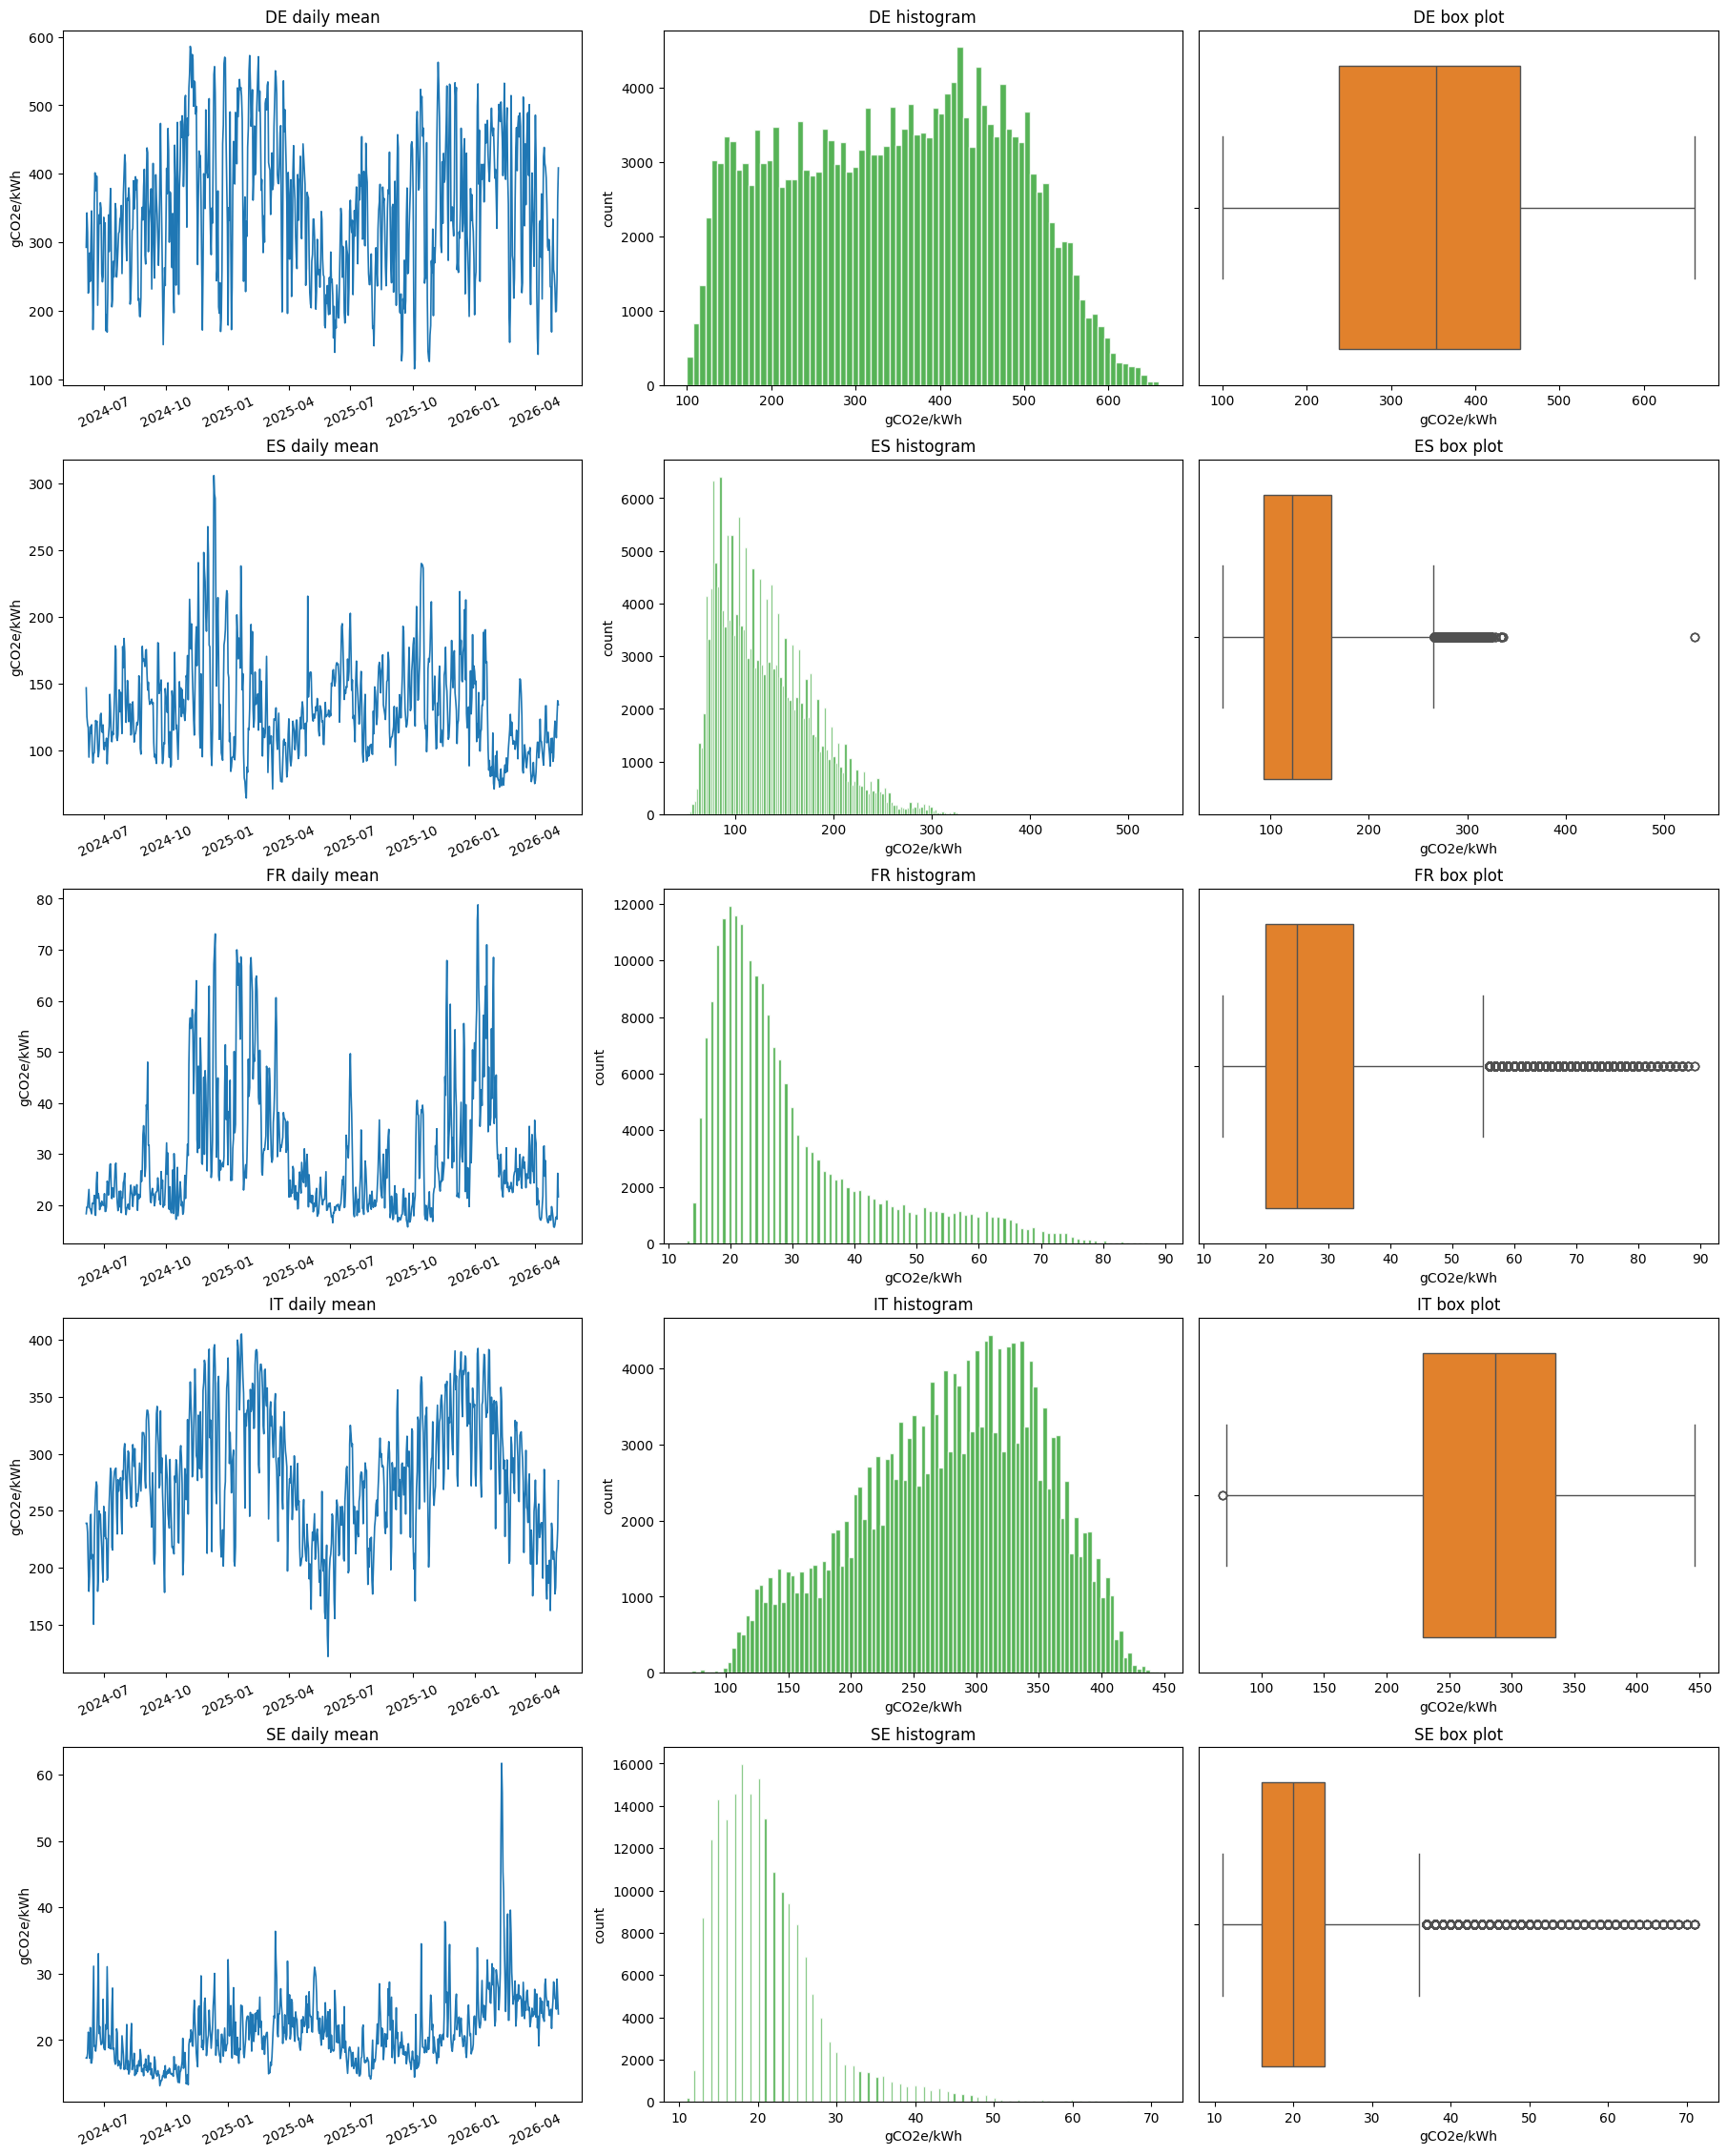

In [2]:
data = load_region_data(DATA_ROOT)
regions = sorted(data["zone"].dropna().unique())

print(f"Loaded {len(data):,} rows across {len(regions)} regions: {', '.join(regions)}")
print(f"Timestamp range: {data['timestamp'].min()} to {data['timestamp'].max()}")
print("\nColumns:", list(data.columns))
display(data.head())
display(data.dtypes.to_frame("dtype"))

coverage = (
    data.groupby("zone")
    .agg(
        rows=("carbonIntensity", "size"),
        start=("timestamp", "min"),
        end=("timestamp", "max"),
        estimated_share=("isEstimated", lambda s: s.astype("float").mean() if s.notna().any() else np.nan),
    )
    .sort_index()
)
display(coverage)

fig, axes = plt.subplots(len(regions), 3, figsize=(18, 4.5 * len(regions)), constrained_layout=True)
if len(regions) == 1:
    axes = np.array([axes])

for row, zone in enumerate(regions):
    zone_data = data.loc[data["zone"] == zone, "carbonIntensity"].dropna().astype(float)
    zone_frame = data[data["zone"] == zone].set_index("timestamp")
    daily_mean = zone_frame["carbonIntensity"].resample("D").mean()
    axes[row, 0].plot(daily_mean.index, daily_mean.values, color="#1f77b4", linewidth=1.2)
    axes[row, 0].set_title(f"{zone} daily mean")
    axes[row, 0].set_ylabel("gCO2e/kWh")
    axes[row, 0].tick_params(axis="x", rotation=25)

    axes[row, 1].hist(zone_data, bins="fd", color="#2ca02c", alpha=0.8, edgecolor="white")
    axes[row, 1].set_title(f"{zone} histogram")
    axes[row, 1].set_xlabel("gCO2e/kWh")
    axes[row, 1].set_ylabel("count")

    sns.boxplot(x=zone_data, ax=axes[row, 2], color="#ff7f0e")
    axes[row, 2].set_title(f"{zone} box plot")
    axes[row, 2].set_xlabel("gCO2e/kWh")

plt.show()

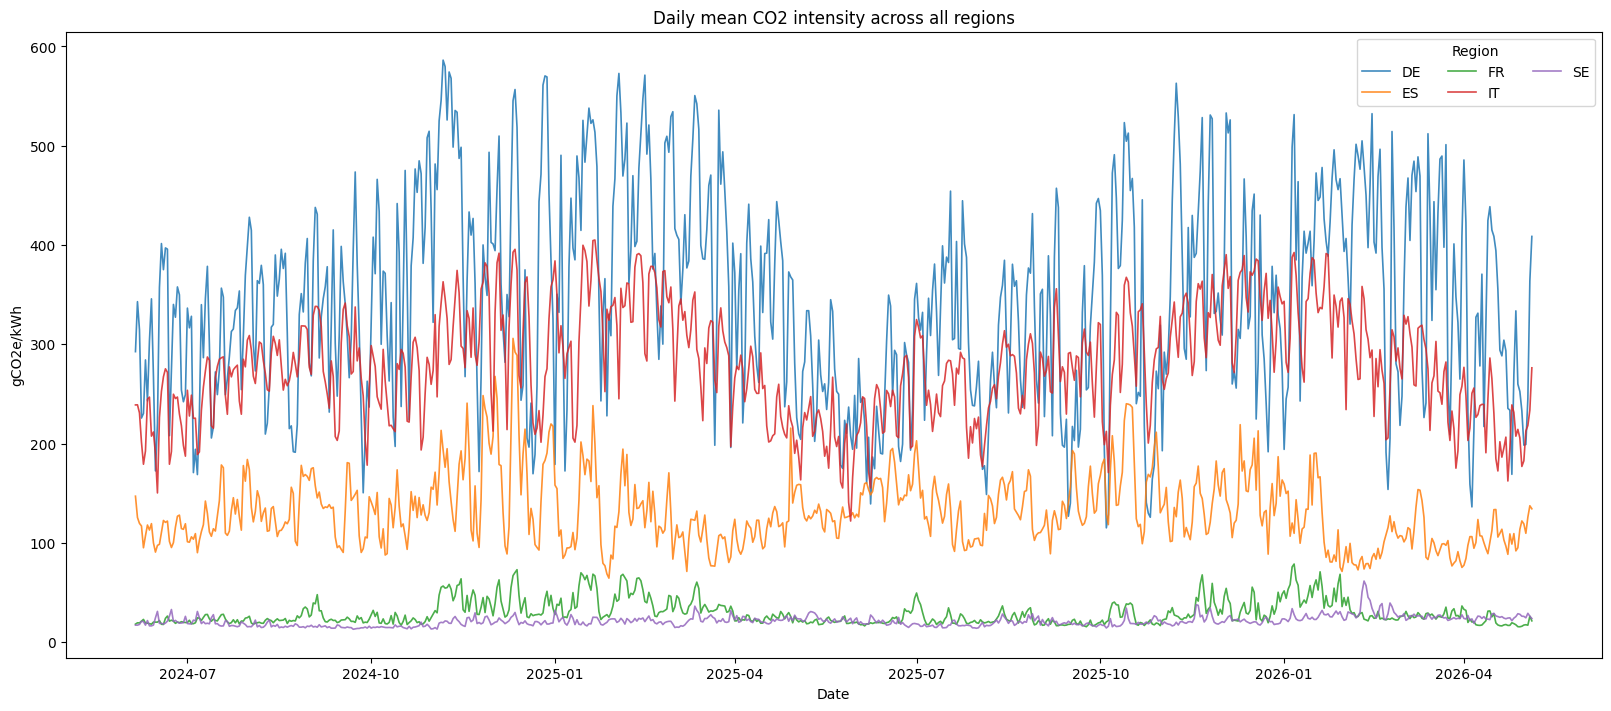

In [3]:
all_country_daily = (
    data.assign(date=data["timestamp"].dt.floor("D"))
    .groupby(["zone", "date"], as_index=False)["carbonIntensity"]
    .mean()
    .sort_values(["date", "zone"])
)

fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)
for zone in regions:
    zone_daily = all_country_daily.loc[all_country_daily["zone"] == zone]
    ax.plot(
        zone_daily["date"],
        zone_daily["carbonIntensity"],
        linewidth=1.2,
        alpha=0.85,
        label=zone,
    )

ax.set_title("Daily mean CO2 intensity across all regions")
ax.set_xlabel("Date")
ax.set_ylabel("gCO2e/kWh")
ax.legend(title="Region", ncols=3, fontsize=10)
fig.savefig("presentation_2/assets/daily_co2_intensity.png", dpi=300, bbox_inches="tight")
plt.show()

## Summary Stats

In [4]:
summary = (
    data.groupby("zone")
    .apply(lambda frame: pd.Series({
        **summarize_region(frame["carbonIntensity"]),
        "share_estimated": frame["isEstimated"].astype("float").mean() if "isEstimated" in frame else np.nan,
    }))
    .sort_index()
)

summary["coefficient_of_variation"] = summary["std_dev"] / summary["mean"]
summary["range"] = summary["max"] - summary["min"]
display(summary)

comparison = data.groupby(["zone", pd.Grouper(key="timestamp", freq="D")])["carbonIntensity"].mean().reset_index()
comparison_table = comparison.pivot(index="timestamp", columns="zone", values="carbonIntensity")
display(comparison_table.tail())

,count,min,max,mean,median,variance,std_dev,coefficient_of_variation,skewness,kurtosis,share_estimated,range
zone,,,,,,,,,,,,
DE,201600.0,100.0,660.0,347.598095,354.0,16701.870069,129.235715,0.371796,-0.022311,-1.039266,0.002619,560.0
ES,201600.0,51.0,531.0,131.904152,122.0,2367.987663,48.661973,0.368919,0.917315,0.567704,0.001726,480.0
FR,201600.0,13.0,89.0,29.399831,25.0,182.995705,13.527591,0.460125,1.491446,1.667836,0.001964,76.0
IT,201600.0,69.0,446.0,279.560987,287.0,5222.321818,72.265634,0.258497,-0.349189,-0.595193,0.021979,377.0
SE,201600.0,11.0,71.0,21.303492,20.0,49.938438,7.066713,0.331716,1.883738,5.520839,0.001488,60.0


zone,DE,ES,FR,IT,SE
timestamp,,,,,
2026-05-01 00:00:00+00:00,198.500000,119.250000,17.364583,182.708333,26.128472
2026-05-02 00:00:00+00:00,199.180556,109.760417,17.697917,212.802083,24.656250
2026-05-03 00:00:00+00:00,244.986111,125.937500,17.218750,218.229167,29.177083
2026-05-04 00:00:00+00:00,363.795139,137.489583,26.197917,233.746528,26.302083
2026-05-05 00:00:00+00:00,408.635417,134.416667,21.604167,276.354167,23.937500


In [5]:
TABLES_DIR = Path("presentation_2/tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)

region_stats = summary[["mean", "std_dev", "coefficient_of_variation"]].copy()
region_stats["mean"] = region_stats["mean"].round(0).astype(int)
metric_table = (
    region_stats
    .rename(columns={
        "mean": "Mean",
        "std_dev": "Std.\\ dev.",
        "coefficient_of_variation": "Coeff.\\ of\\ variation",
    })
    .rename_axis("Region")
    .reset_index()
)
metric_table.to_latex(
    TABLES_DIR / "metric_table.tex",
    index=False,
    escape=False,
    float_format="%.2f",
)

## Assess Sample Independence

Because the underlying data are 5-minute time series, the ACF is most useful for the selected region after keeping the series at a fixed interval and looking at short lags. Strong daily structure is expected.

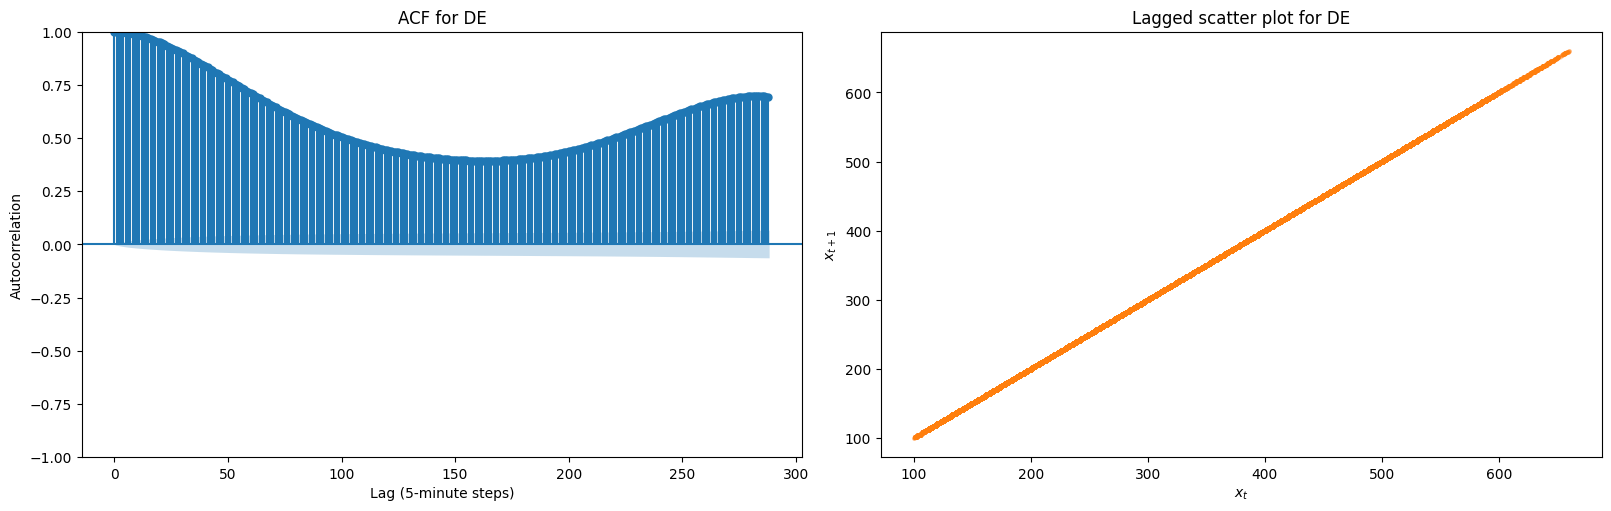

Selected region: DE
Lag-1 autocorrelation: 0.9994729023974662
Lag-288 autocorrelation (one day): 0.6943980457579605


In [6]:
analysis_region = "DE"
region_series = (
    data.loc[data["zone"] == analysis_region]
    .sort_values("timestamp")
    .set_index("timestamp")["carbonIntensity"]
    .astype(float)
    .resample("5min")
    .mean()
    .interpolate(limit=6)
)

lags, acf_values = empirical_acf(region_series, max_lags=288)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
plot_acf(region_series, lags=288, ax=axes[0], zero=True)
axes[0].set_title(f"ACF for {analysis_region}")
axes[0].set_xlabel("Lag (5-minute steps)")
axes[0].set_ylabel("Autocorrelation")

lagged = pd.DataFrame({"x_t": region_series.iloc[:-1], "x_t_plus_1": region_series.iloc[1:]})
axes[1].scatter(lagged["x_t"], lagged["x_t_plus_1"], s=6, alpha=0.2, color="#ff7f0e")
axes[1].set_title(f"Lagged scatter plot for {analysis_region}")
axes[1].set_xlabel(r"$x_t$")
axes[1].set_ylabel(r"$x_{t+1}$")

fig.savefig("presentation_2/assets/acf_lag.png", dpi=300, bbox_inches="tight")
plt.show()

print("Selected region:", analysis_region)
print("Lag-1 autocorrelation:", float(acf_values[1]))
print("Lag-288 autocorrelation (one day):", float(acf_values[288]))

## Hypothesize Distribution Family

The summary statistics and histograms are used to narrow down candidates. For positive, right-skewed CO2 intensity data, gamma, Weibull, lognormal, and exponential are the first families to test.

Candidate-selection region: DE


,count,min,max,mean,median,variance,std_dev,coefficient_of_variation,skewness,kurtosis,share_estimated
0,201600.0,100.0,660.0,347.598095,354.0,16701.870069,129.235715,0.371796,-0.022311,-1.039266,0.002619


Heuristic candidate hint from CV=0.372 and skewness=-0.022: gamma or Weibull with shape > 1


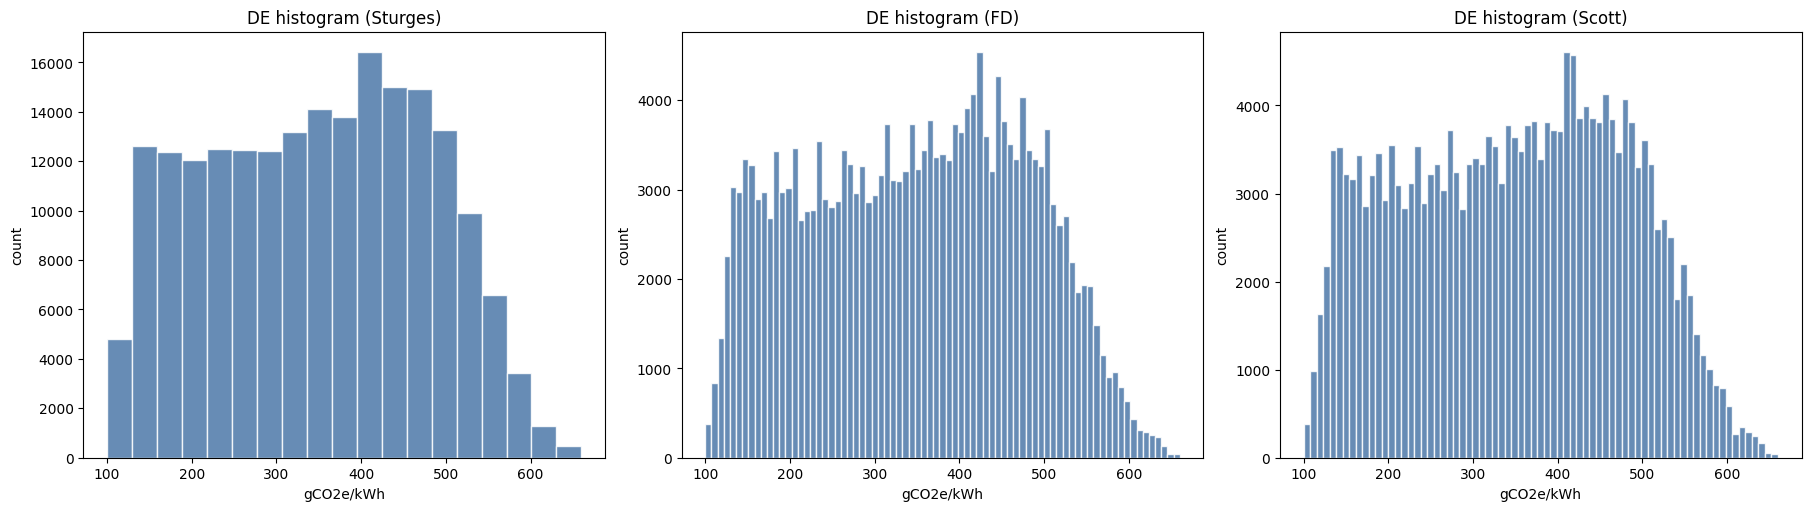

In [7]:
focus_frame = data.loc[data["zone"] == analysis_region].copy()
focus_series = focus_frame["carbonIntensity"].dropna().astype(float)
focus_summary = summarize_region(focus_series)
focus_summary["share_estimated"] = focus_frame["isEstimated"].astype("float").mean() if "isEstimated" in focus_frame else np.nan

print(f"Candidate-selection region: {analysis_region}")
display(focus_summary.to_frame().T)

cv = float(focus_summary["coefficient_of_variation"])
skew = float(focus_summary["skewness"])
if cv < 0.8:
    hint = "gamma or Weibull with shape > 1"
elif cv < 1.2:
    hint = "exponential-like or gamma"
else:
    hint = "lognormal, Weibull, or a more flexible positive family"
print(f"Heuristic candidate hint from CV={cv:.3f} and skewness={skew:.3f}: {hint}")

bin_rules = {
    "Sturges": max(8, int(np.ceil(np.log2(len(focus_series)) + 1))),
    "FD": "fd",
    "Scott": "scott",
}
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for ax, (label, bins) in zip(axes, bin_rules.items(), strict=False):
    ax.hist(focus_series, bins=bins, color="#4c78a8", alpha=0.85, edgecolor="white")
    ax.set_title(f"{analysis_region} histogram ({label})")
    ax.set_xlabel("gCO2e/kWh")
    ax.set_ylabel("count")
plt.show()

## Estimate Distribution Parameters

In [8]:
fit_rows: list[dict[str, object]] = []
fit_details: dict[str, pd.DataFrame] = {}

for zone, frame in data.groupby("zone", sort=True):
    zone_series = frame["carbonIntensity"].dropna().astype(float)
    zone_rows = []
    for dist_name, dist in DIST_CANDIDATES.items():
        params, loglik, aic = fit_distribution(zone_series, dist)
        zone_rows.append({
            "zone": zone,
            "distribution": dist_name,
            "log_likelihood": loglik,
            "aic": aic,
            "params": params,
        })
    zone_table = pd.DataFrame(zone_rows).sort_values("aic").reset_index(drop=True)
    zone_table["rank"] = np.arange(1, len(zone_table) + 1)
    fit_details[zone] = zone_table
    fit_rows.extend(zone_table.to_dict("records"))

fit_summary = pd.DataFrame(fit_rows).sort_values(["zone", "aic"]).reset_index(drop=True)
display(fit_summary)

best_fit_per_region = (
    fit_summary.sort_values(["zone", "aic"])
    .groupby("zone", as_index=False)
    .first()[["zone", "distribution", "aic", "params"]]
)
display(best_fit_per_region)

focus_fit_table = fit_details[analysis_region]
display(focus_fit_table)

,zone,distribution,log_likelihood,aic,params,rank
0,DE,weibull,-1.262341e+06,2.524689e+06,"(3.0120843602412166, 0, 390.31543679221)",1
1,DE,normal,-1.266164e+06,2.532331e+06,"(347.59809523809525, 129.23539461990418)",2
2,DE,gamma,-1.269095e+06,2.538195e+06,"(6.293608074111432, 0, 55.23033705704198)",3
3,DE,lognormal,-1.276320e+06,2.552645e+06,"(0.42422546141033535, 0, 320.37833887401905)",4
4,DE,exponential,-1.381171e+06,2.762346e+06,"(0.0, 347.59809523809525)",5
5,ES,lognormal,-1.048440e+06,2.096886e+06,"(0.35468129722911496, 0, 123.74128090742535)",1
6,ES,gamma,-1.052127e+06,2.104259e+06,"(7.989870480555116, 0, 16.50892240452813)",2
7,ES,weibull,-1.065133e+06,2.130271e+06,"(2.8539659255111456, 0, 148.15553222805434)",3
8,ES,normal,-1.069253e+06,2.138510e+06,"(131.90415178571428, 48.661852793399525)",4
9,ES,exponential,-1.185826e+06,2.371657e+06,"(0.0, 131.90415178571428)",5


,zone,distribution,aic,params
0,DE,weibull,2.524689e+06,"(3.0120843602412166, 0, 390.31543679221)"
1,ES,lognormal,2.096886e+06,"(0.35468129722911496, 0, 123.74128090742535)"
2,FR,lognormal,1.527855e+06,"(0.39663507852513474, 0, 26.980305907573353)"
3,IT,weibull,2.290197e+06,"(4.552408924386345, 0, 306.7920776762577)"
4,SE,lognormal,1.287966e+06,"(0.2898792793152588, 0, 20.362543452986106)"


,zone,distribution,log_likelihood,aic,params,rank
0,DE,weibull,-1.262341e+06,2.524689e+06,"(3.0120843602412166, 0, 390.31543679221)",1
1,DE,normal,-1.266164e+06,2.532331e+06,"(347.59809523809525, 129.23539461990418)",2
2,DE,gamma,-1.269095e+06,2.538195e+06,"(6.293608074111432, 0, 55.23033705704198)",3
3,DE,lognormal,-1.276320e+06,2.552645e+06,"(0.42422546141033535, 0, 320.37833887401905)",4
4,DE,exponential,-1.381171e+06,2.762346e+06,"(0.0, 347.59809523809525)",5


## Compare Best Fits Across Regions

This figure overlays each region's best-fitting distribution twice: first on the raw CO2 intensity scale, then on a standardized z-score scale so the fitted shapes can be compared independent of each country's absolute intensity level.


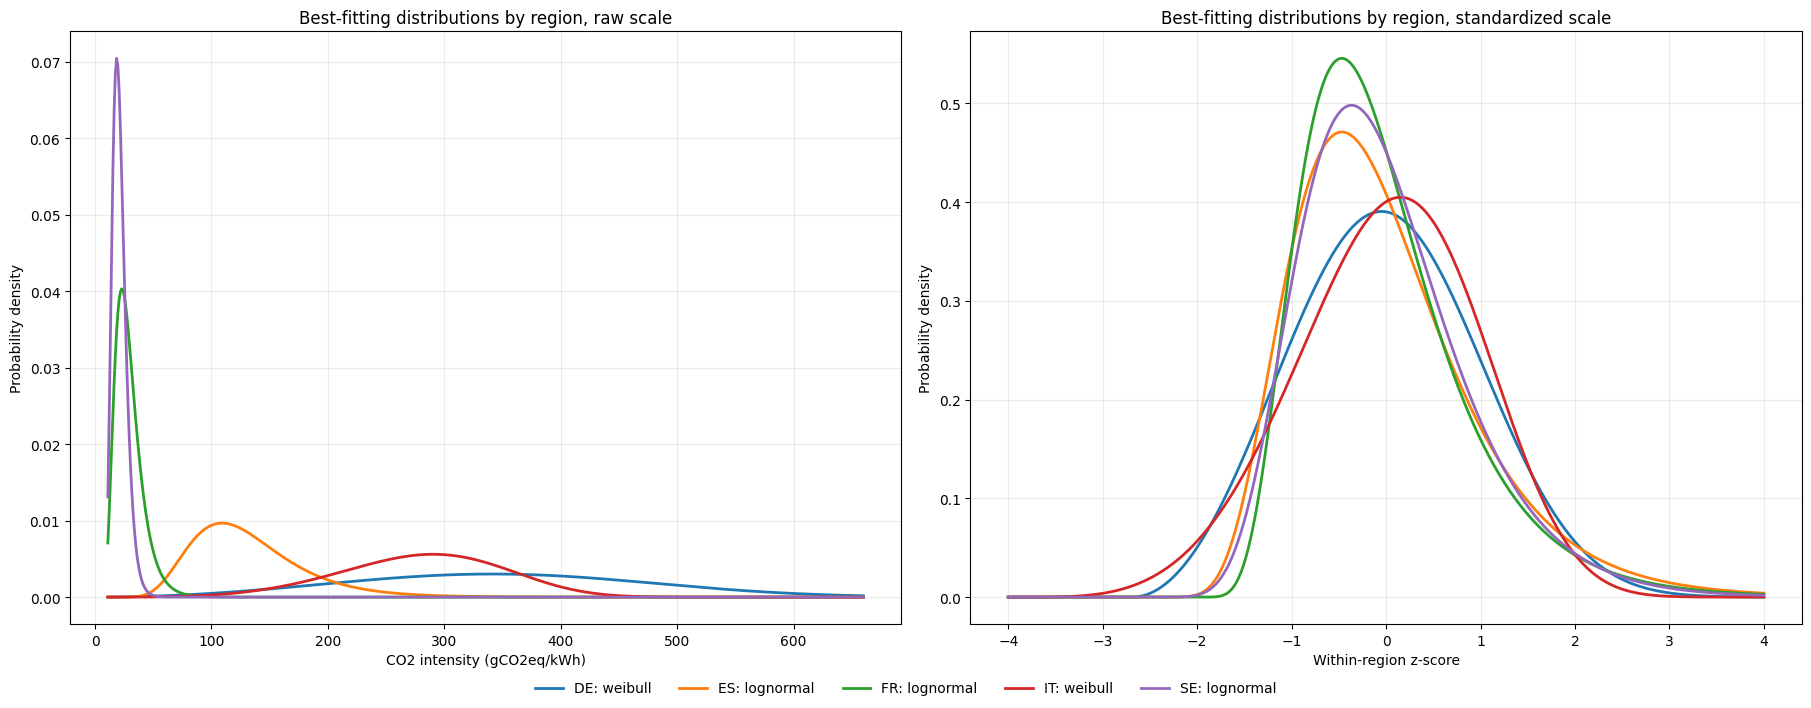

In [9]:
global_min = data["carbonIntensity"].min()
global_max = data["carbonIntensity"].max()
x_grid = np.linspace(global_min, global_max, 600)
z_grid = np.linspace(-4, 4, 600)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

for zone in regions:
    zone_series = data.loc[data["zone"] == zone, "carbonIntensity"].dropna().astype(float)
    mean = zone_series.mean()
    std = zone_series.std(ddof=0)
    best_row = best_fit_per_region.loc[best_fit_per_region["zone"] == zone].iloc[0]
    dist = DIST_CANDIDATES[best_row["distribution"]]
    params = best_row["params"]

    raw_pdf = dist.pdf(x_grid, *params)
    standardized_pdf = dist.pdf(mean + std * z_grid, *params) * std

    label = f"{zone}: {best_row['distribution']}"
    axes[0].plot(x_grid, raw_pdf, linewidth=2, label=label)
    axes[1].plot(z_grid, standardized_pdf, linewidth=2, label=label)

axes[0].set_title("Best-fitting distributions by region, raw scale")
axes[0].set_xlabel("CO2 intensity (gCO2eq/kWh)")
axes[0].set_ylabel("Probability density")
axes[0].grid(True, alpha=0.25)

axes[1].set_title("Best-fitting distributions by region, standardized scale")
axes[1].set_xlabel("Within-region z-score")
axes[1].set_ylabel("Probability density")
axes[1].grid(True, alpha=0.25)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=min(len(regions), 5), frameon=False)
fig.savefig("presentation_2/assets/best_fit_distributions.png", dpi=300, bbox_inches="tight")
plt.show()


## Q-Q and P-P Plots

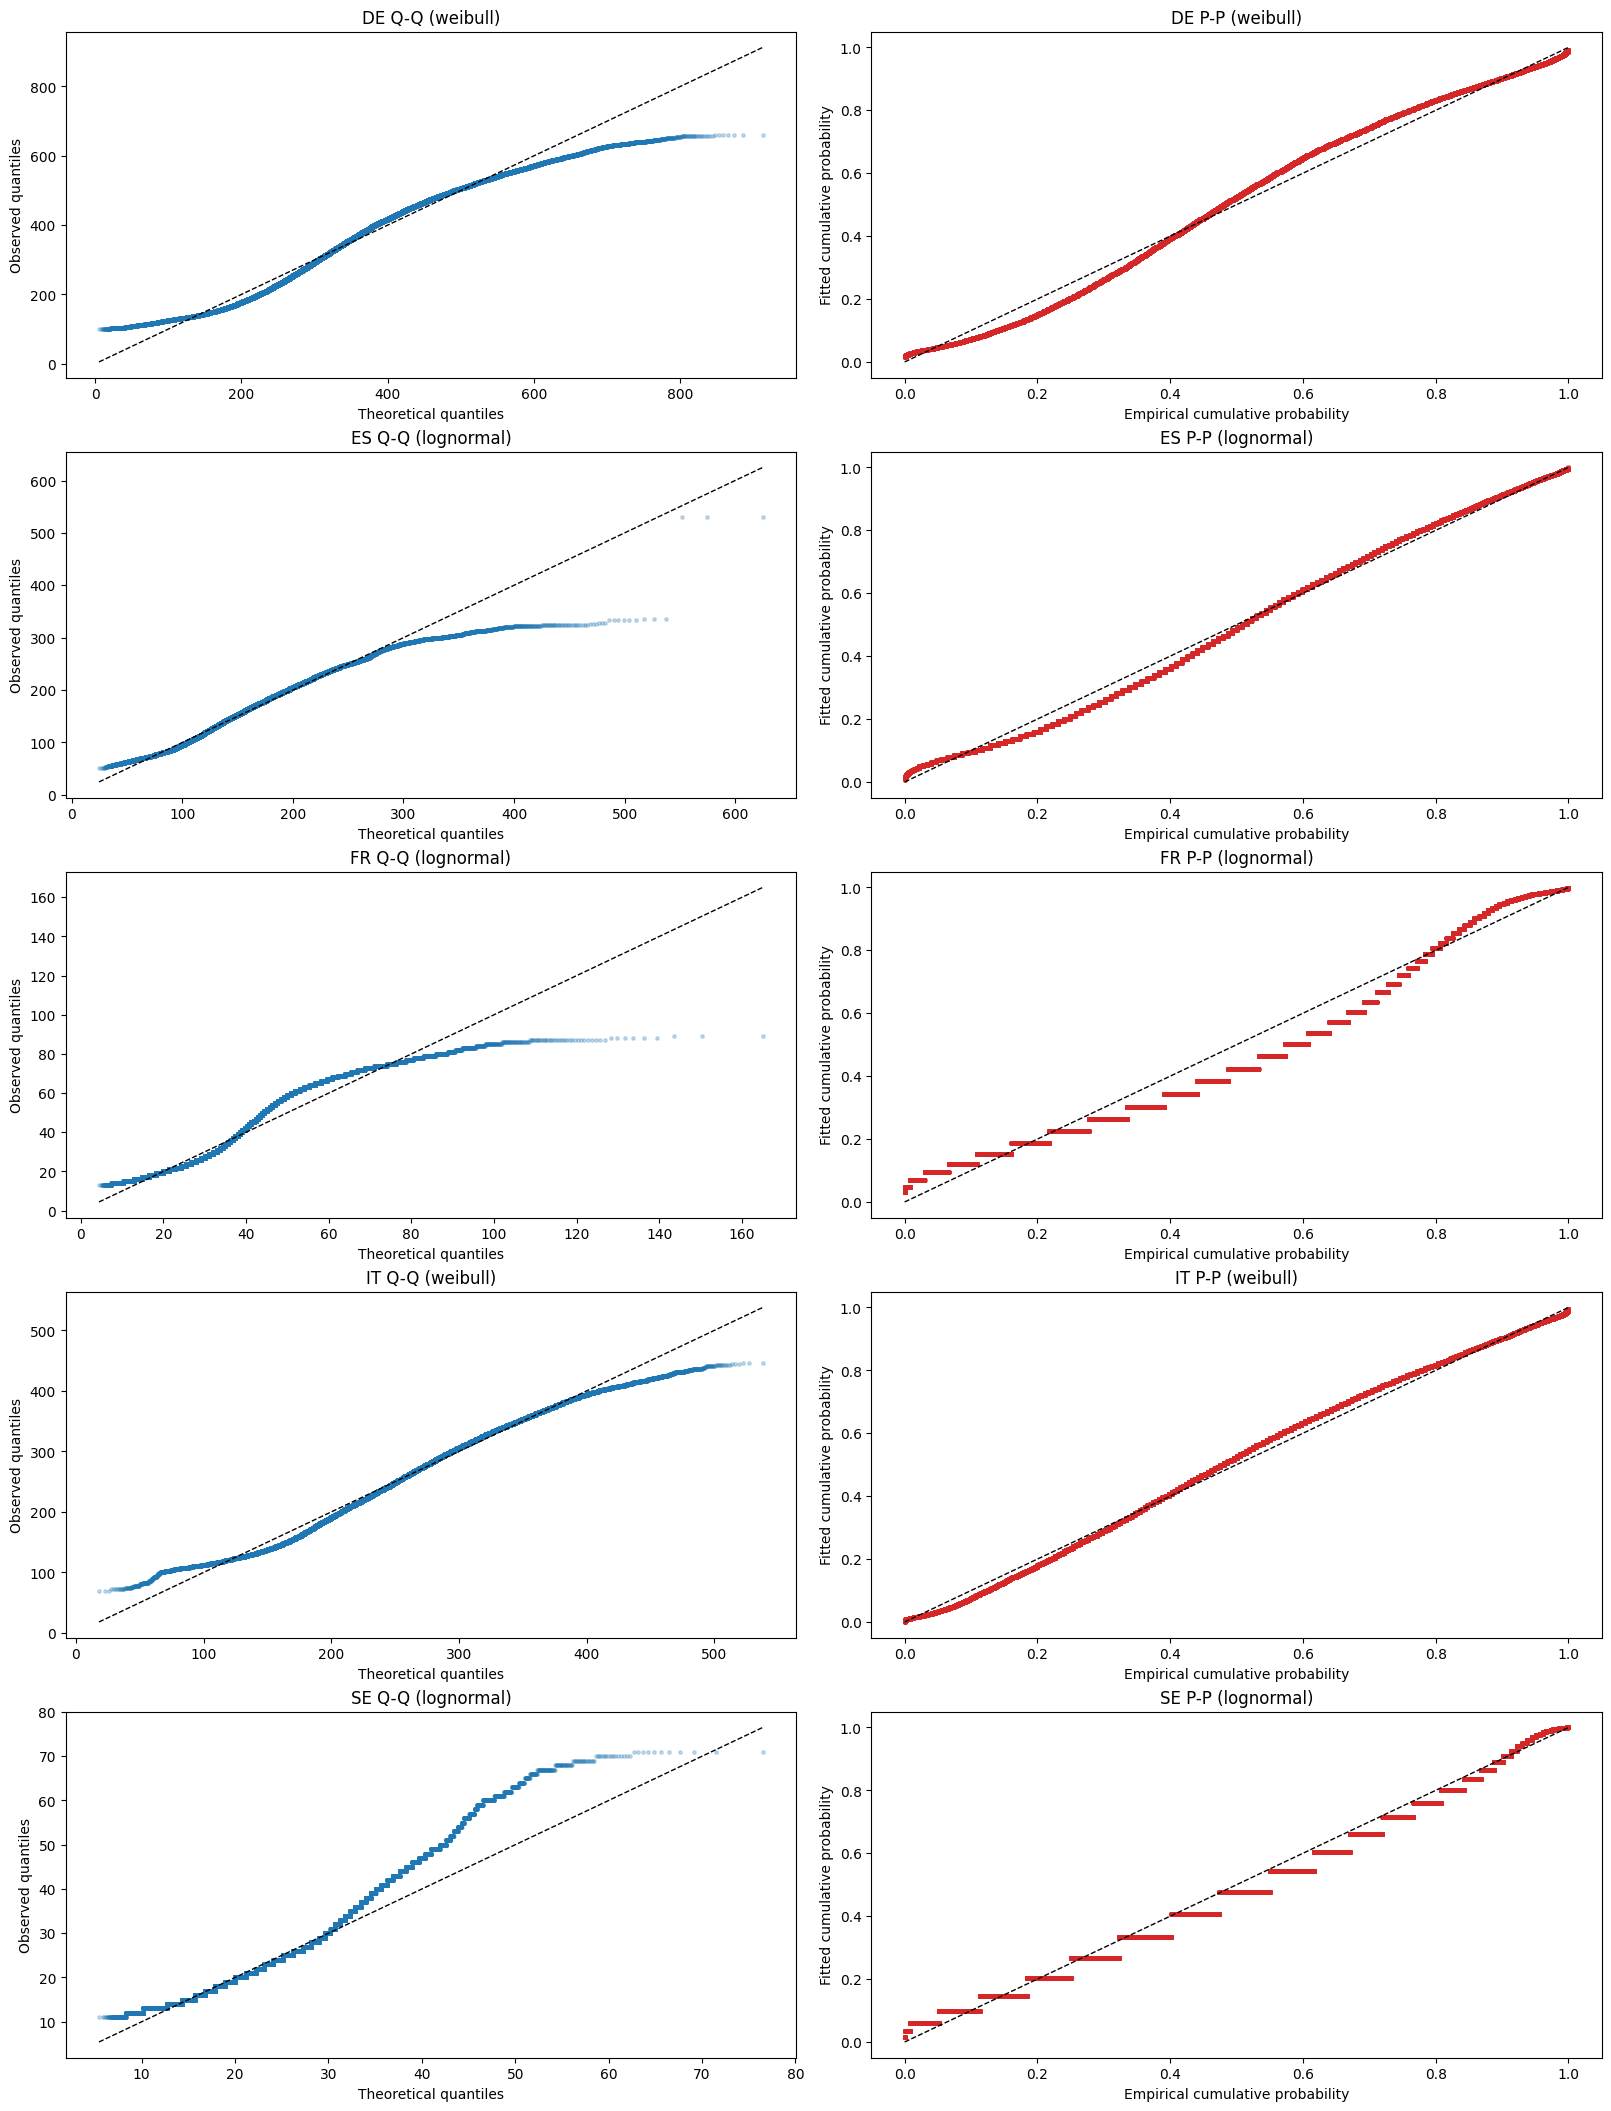

In [10]:
fig, axes = plt.subplots(len(regions), 2, figsize=(16, 4.2 * len(regions)), constrained_layout=True)
if len(regions) == 1:
    axes = np.array([axes])

for row_idx, zone in enumerate(regions):
    zone_series = data.loc[data["zone"] == zone, "carbonIntensity"].dropna().astype(float)
    best_row = best_fit_per_region.loc[best_fit_per_region["zone"] == zone].iloc[0]
    dist = DIST_CANDIDATES[best_row["distribution"]]
    params = best_row["params"]

    qq_emp, qq_theo = qq_data(zone_series, dist, params)
    pp_emp, pp_fit = pp_data(zone_series, dist, params)

    ax_qq = axes[row_idx, 0]
    ax_pp = axes[row_idx, 1]

    ax_qq.scatter(qq_theo, qq_emp, s=6, alpha=0.25, color="#1f77b4")
    qq_min = min(qq_theo.min(), qq_emp.min())
    qq_max = max(qq_theo.max(), qq_emp.max())
    ax_qq.plot([qq_min, qq_max], [qq_min, qq_max], color="black", linestyle="--", linewidth=1)
    ax_qq.set_title(f"{zone} Q-Q ({best_row['distribution']})")
    ax_qq.set_xlabel("Theoretical quantiles")
    ax_qq.set_ylabel("Observed quantiles")

    ax_pp.scatter(pp_emp, pp_fit, s=6, alpha=0.25, color="#d62728")
    ax_pp.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
    ax_pp.set_title(f"{zone} P-P ({best_row['distribution']})")
    ax_pp.set_xlabel("Empirical cumulative probability")
    ax_pp.set_ylabel("Fitted cumulative probability")

fig.savefig("presentation_2/assets/qq_pp_plots.png", dpi=300, bbox_inches="tight")
plt.show()